# Clasificación Multiclase — Regresión Logística One-vs-All

## Introducción

En este cuaderno se implementa la clasificación multiclase mediante el método **One-vs-All** utilizando regresión logística, aplicado al reconocimiento de dígitos del dataset **SVHN (Street View House Numbers)**.

Se desarrollan desde cero las funciones de normalización, costo y descenso por el gradiente, y se comparan dos métodos de optimización: descenso por el gradiente manual y el optimizador `scipy.optimize.minimize`. Antes de ejecutar las celdas de código se importan todas las librerías necesarias.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np
import pandas as pd

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# modulo para cargar archivos en formato MATLAB
from scipy.io import loadmat

# division de datos
from sklearn.model_selection import train_test_split

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1. Clasificación Multiclase

La regresión logística One-vs-All entrena un clasificador binario independiente por cada clase. Para predecir, se calcula la probabilidad de cada clasificador y se elige la clase con mayor valor.

### 1.1 Dataset — SVHN (Street View House Numbers)

Se utiliza el dataset **SVHN Formato 2**, disponible en http://ufldl.stanford.edu/housenumbers/. Contiene imágenes de dígitos recortados de fotografías reales de calles, letreros y placas de casas.

**Características del dataset:**
- Archivo: `train_32x32.mat` — formato MATLAB, se carga con `loadmat` de `scipy.io`
- Cada imagen: **32×32 píxeles en color RGB** → convertida a escala de grises → **1024 features** (n > 100 ✓)
- Total de imágenes: **73 257** (m > 5000 ✓)
- Clases: **10 dígitos (0–9)**; en el archivo original el dígito 0 está etiquetado como 10 por convención de MATLAB

**Preprocesamiento aplicado con Pandas:**
1. Conversión de RGB a escala de grises usando la fórmula estándar: $0.299R + 0.587G + 0.114B$
2. Normalización de píxeles al rango $[0, 1]$
3. Balanceo de clases: se toman exactamente **N ejemplos por clase** (N = mínimo entre todas las clases) mediante submuestreo aleatorio con Pandas
4. División **80% entrenamiento / 20% prueba** con estratificación — los datos de prueba no participan en el entrenamiento

La matriz de datos queda definida como:

$$ X = \begin{bmatrix} - \: (x^{(1)})^T \: - \\ -\: (x^{(2)})^T \:- \\ \vdots \\ - \: (x^{(m)})^T \:-  \end{bmatrix} $$

donde cada fila es una imagen aplanada de 1024 valores, y el vector $y$ contiene las etiquetas de 0 a 9.

In [ ]:
# Ingresar imágenes de dígitos de 32x32 color en excala de grises 1024
input_layer_size  = 1024   # 32 * 32 * 1

# 10 etiquetas, de 0 a 9
num_labels = 10

# datos de entrenamiento almacenados en los arreglos X, y
data = loadmat('/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 4/lab 4(2)/train_32x32.mat')

# X tiene shape (32, 32, 3, m) -> transponer a (m, 3072)
X_rgb = data['X'].transpose(3, 0, 1, 2).astype(float)
y_full = data['y'].ravel().astype(int)
# Convertir a escala de grises: promedio ponderado de canales RGB
# fórmula estándar: 0.299*R + 0.587*G + 0.114*B
X_full = (0.299 * X_rgb[:,:,:,0] +
          0.587 * X_rgb[:,:,:,1] +
          0.114 * X_rgb[:,:,:,2])

# Aplanar a (m, 1024)
X_full = X_full.reshape(-1, 32*32)
# establecer el dígito cero en 0, en lugar del 10 asignado a este conjunto de datos
y_full[y_full == 10] = 0

# normalizar pixeles a [0, 1]
X_full = X_full / 255.0
# --- Balanceo con Pandas: igual número de ejemplos por clase ---
df = pd.DataFrame(X_full)
df['label'] = y_full

# Contar ejemplos por clase antes del balanceo
class_counts = df['label'].value_counts().sort_index()
print(f'Counts per class before balancing: {class_counts.to_dict()}')

# N = mínimo entre todas las clases → todas quedan igual
N = class_counts.min()
print(f'Muestras por clase (mínimo): {N}')

partes = [df[df['label'] == c].sample(N, random_state=42) for c in range(num_labels)]
df_bal = pd.concat(partes, ignore_index=True)

X_bal = df_bal.drop('label', axis=1).values
y_bal = df_bal['label'].values

# --- Division 80% entrenamiento / 20% prueba ---
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=42, stratify=y_bal
)

X, y = X_train, y_train
m = y.size

print(f'Entrenamiento: X={X.shape}, y={y.shape}')
print(f'Prueba:        X={X_test.shape}, y={y_test.shape}')
print(f'Clases balanceadas: {pd.Series(y_bal).value_counts().sort_index().to_dict()}')


Counts per class before balancing: {0: 4948, 1: 13861, 2: 10585, 3: 8497, 4: 7458, 5: 6882, 6: 5727, 7: 5595, 8: 5045, 9: 4659}
Muestras por clase (mínimo): 4659
Entrenamiento: X=(37272, 1024), y=(37272,)
Prueba:        X=(9318, 1024), y=(9318,)
Clases balanceadas: {0: 4659, 1: 4659, 2: 4659, 3: 4659, 4: 4659, 5: 4659, 6: 4659, 7: 4659, 8: 4659, 9: 4659}


In [ ]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Dec  5 21:09:26 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[[[ 33,  84,  19, ...,  92, 190, 216],
          [ 30,  76,  54, ...,  78, 188, 217],
          [ 38,  59, 110, ..., 101, 191, 212]],
 
         [[ 15,  86,  20, ...,  94, 205, 221],
          [ 23,  73,  52, ...,  82, 203, 222],
          [ 19,  66, 111, ..., 105, 206, 217]],
 
         [[ 15,  77,  25, ..., 114, 220, 226],
          [ 17,  78,  57, ..., 101, 218, 227],
          [ 19,  56, 116, ..., 125, 220, 221]],
 
         ...,
 
         [[ 72,  90,  65, ..., 200, 229, 200],
          [ 65,  78, 144, ..., 201, 231, 199],
          [ 56,  69, 223, ..., 203, 224, 191]],
 
         [[ 82,  88,  78, ..., 192, 229, 193],
          [ 77,  77, 148, ..., 193, 229, 188],
          [ 57,  67, 218, ..., 195, 224, 182]],
 
         [[ 89,  88,  98, ..., 190, 229, 197],
          [ 79,  78, 158, ..., 191, 228, 189],
          [ 59,  66, 220, 

In [ ]:
print(m)

37272


### 1.2 Visualización de los datos

Se seleccionan aleatoriamente 100 imágenes del conjunto de entrenamiento para verificar visualmente que la conversión a escala de grises y el preprocesamiento se aplicaron correctamente. Cada imagen de 1024 valores se reorganiza en una matriz de 32×32 píxeles para mostrarla. Es normal ver dígitos vecinos en los bordes de las imágenes — esto es característico de SVHN, ya que las imágenes fueron recortadas de fotografías de placas con múltiples números.

In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(32, 32), cmap='gray')
        ax.axis('off')

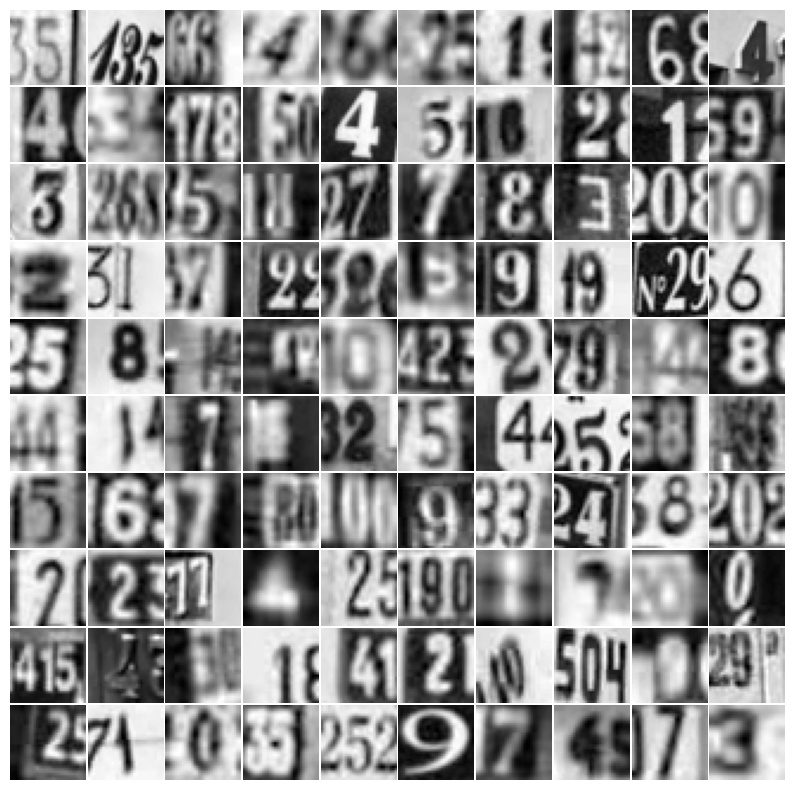

In [ ]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

### 1.3 Funciones del modelo

#### 1.3.1 Normalización Z-score

Antes de entrenar se normalizan los features restando la media y dividiendo por la desviación estándar. Esto es indispensable para que el descenso por el gradiente converja correctamente, ya que sin normalización los features con valores grandes dominan el gradiente y el modelo no aprende.

#### 1.3.2 Función de costo

La función sigmoide $g(z) = \frac{1}{1+e^{-z}}$ convierte cualquier valor real a una probabilidad entre 0 y 1. La función de costo mide qué tan mal están los parámetros $\theta$ actuales:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log \left( h_\theta\left( x^{(i)} \right) \right) - \left(1 - y^{(i)} \right) \log \left(1 - h_\theta \left( x^{(i)} \right) \right) \right] $$

donde $h_\theta(x^{(i)}) = g(\theta^T x^{(i)})$. El objetivo es minimizar $J(\theta)$.

#### 1.3.3 Descenso por el gradiente

El gradiente del costo indica la dirección de mayor crecimiento. Para minimizar el costo, se actualizan los parámetros en la dirección opuesta al gradiente:

$$ \theta := \theta - \frac{\alpha}{m} X^T \left( h_\theta(X) - y \right) $$

donde $\alpha$ es la tasa de aprendizaje. Este proceso se repite `num_iters` veces.

In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def featureNormalize(X):
    mu    = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [ ]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    eps = 1e-12
    J = (1/m) * np.sum(-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps))
    return J

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history   = []
    acc_history = []

    for _ in range(num_iters):
        h      = sigmoid(X.dot(theta))
        theta -= (alpha / m) * X.T.dot(h - y)
        J_history.append(calcularCosto(theta, X, y))
        acc_history.append(np.mean((h >= 0.5).astype(int) == y) * 100)

    return theta, J_history, acc_history

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo w.r.t. a los parámetros.

    Parametros
    ----------
    theta : array_like
        Parametro theta de la regresion logistica. Vector de la forma(shape) (n, ). n es el numero de caracteristicas
        incluida la intercepcion

    X : array_like
        Dataset con la forma(shape) (m x n). m es el numero de ejemplos, y n es el numero de
        caracteristicas (incluida la intercepcion).

    y : array_like
        El conjunto de etiquetas. Un vector con la forma (shape) (m, ). m es el numero de ejemplos

    lambda_ : float
        Parametro de regularización.

    Devuelve
    -------
    J : float
        El valor calculado para la funcion de costo regularizada.

    grad : array_like
        Un vector de la forma (shape) (n, ) que es el gradiente de la
        función de costo con respecto a theta, en los valores actuales de theta..
    """
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # grad = (1 / m) * (h - y).dot(X)
    # grad = grad + (lambda_ / m) * temp

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

#### 1.3.4 Función de costo regularizada

Para evitar el sobreajuste (*overfitting*), se agrega un término de regularización L2 que penaliza valores grandes de $\theta$. El parámetro $\lambda$ controla la fuerza de la regularización:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log \left(h_\theta\left(x^{(i)} \right)\right) - \left( 1 - y^{(i)} \right) \log\left(1 - h_\theta \left(x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

Importante: el término de sesgo $\theta_0$ **no se regulariza**. Esta función es utilizada por `oneVsAllOM` junto con `scipy.optimize.minimize`.

### 1.4 Entrenamiento — Clasificación One-vs-All

Se implementan **dos versiones** del clasificador One-vs-All para comparar su efectividad:

**`oneVsAll` — Descenso por el gradiente manual:**
Utiliza las funciones `featureNormalize`, `calcularCosto` y `descensoGradiente` implementadas desde cero. El parámetro $\alpha$ (tasa de aprendizaje) y el número de iteraciones se controlan manualmente. Al finalizar, grafica la curva de costo y la curva de precisión binaria por clase.

**`oneVsAllOM` — Optimizador de scipy:**
Utiliza `scipy.optimize.minimize` con el método Gradiente Conjugado (CG) y la función `lrCostFunction` regularizada. El optimizador ajusta automáticamente el tamaño del paso en cada iteración, lo que generalmente encuentra el mínimo más eficientemente.

En ambos casos, para cada clase $c \in \{0,...,9\}$:
- Se crea un vector binario $y_{bin}$ donde $y_{bin}^{(i)} = 1$ si $y^{(i)} = c$, y 0 en caso contrario
- Se entrena un clasificador con esa etiqueta binaria
- Los parámetros $\theta_c$ aprendidos se guardan como fila $c$ de `all_theta`

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.

    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n).
    y : array_like
        The data labels. A vector of shape (m, ).
    num_labels : int
        Number of possible labels.
    lambda_ : float
        The logistic regularization parameter.

    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1).
    """
    m, n = X.shape

    all_theta    = np.zeros((num_labels, n + 1))
    all_J_hist   = []
    all_acc_hist = []
    colores      = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd',
                    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
    alpha     = 0.01
    num_iters = 4000

    # Normalización Z-score
    X_norm, mu, sigma = featureNormalize(X)

    # Agrega unos a la matriz X
    X_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        y_actual      = np.where(y == c, 1, 0).astype(float)

        theta, J_history, acc_history = descensoGradiente(
            initial_theta, X_norm, y_actual, alpha, num_iters
        )

        all_theta[c] = theta
        all_J_hist.append(J_history)
        all_acc_hist.append(acc_history)

    iteraciones = np.arange(1, num_iters + 1)

    # Grafica de costo
    fig1, ax1 = pyplot.subplots(figsize=(10, 6))
    for c in range(num_labels):
        ax1.plot(iteraciones, all_J_hist[c], lw=2, color=colores[c],
                 label=f'Clase {c}')
    ax1.set_xlabel('Numero de iteraciones')
    ax1.set_ylabel('Costo J')
    ax1.set_title('Curva del Costo — One-vs-All SVHN')
    ax1.legend(ncol=2)
    ax1.grid(True, linestyle='--', alpha=0.5)
    pyplot.tight_layout()
    pyplot.show()

    # Grafica de precision
    fig2, ax2 = pyplot.subplots(figsize=(10, 6))
    for c in range(num_labels):
        ax2.plot(iteraciones, all_acc_hist[c], lw=2, color=colores[c],
                 label=f'Clase {c}')
    ax2.set_xlabel('Numero de iteraciones')
    ax2.set_ylabel('Precision (%)')
    ax2.set_title('Curva de Precision — One-vs-All SVHN')
    ax2.legend(ncol=2)
    ax2.grid(True, linestyle='--', alpha=0.5)
    pyplot.tight_layout()
    pyplot.show()

    return all_theta, mu, sigma

In [ ]:
def oneVsAllOM(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.

    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n).
    y : array_like
        The data labels. A vector of shape (m, ).
    num_labels : int
        Number of possible labels.
    lambda_ : float
        The logistic regularization parameter.

    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1).
    """
    m, n = X.shape

    all_theta  = np.zeros((num_labels, n + 1))
    all_J_hist = []
    colores    = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd',
                  '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

    # Normalización Z-score
    X_norm, mu, sigma = featureNormalize(X)

    # Agrega unos a la matriz X
    X_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        J_history     = []

        def callback(theta):
            J, _ = lrCostFunction(theta, X_norm, (y == c), lambda_)
            J_history.append(J)

        options = {'maxiter': 100}
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X_norm, (y == c), lambda_),
            jac=True,
            method='CG',
            callback=callback,
            options=options
        )

        all_theta[c] = res.x
        all_J_hist.append(J_history)
        print(f'Clase {c} — costo final: {res.fun:.4f}')

    # Grafica de costo
    fig1, ax1 = pyplot.subplots(figsize=(10, 6))
    for c in range(num_labels):
        ax1.plot(np.arange(1, len(all_J_hist[c]) + 1), all_J_hist[c],
                 lw=2, color=colores[c], label=f'Clase {c}')
    ax1.set_xlabel('Numero de iteraciones')
    ax1.set_ylabel('Costo J')
    ax1.set_title('Curva del Costo — One-vs-All OM SVHN')
    ax1.legend(ncol=2)
    ax1.grid(True, linestyle='--', alpha=0.5)
    pyplot.tight_layout()
    pyplot.show()

    return all_theta, mu, sigma

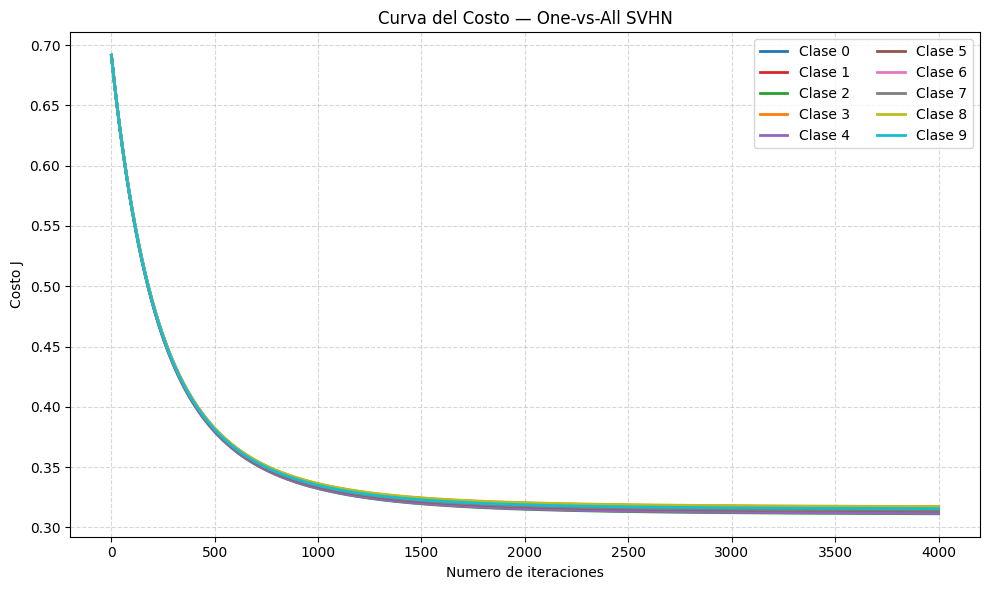

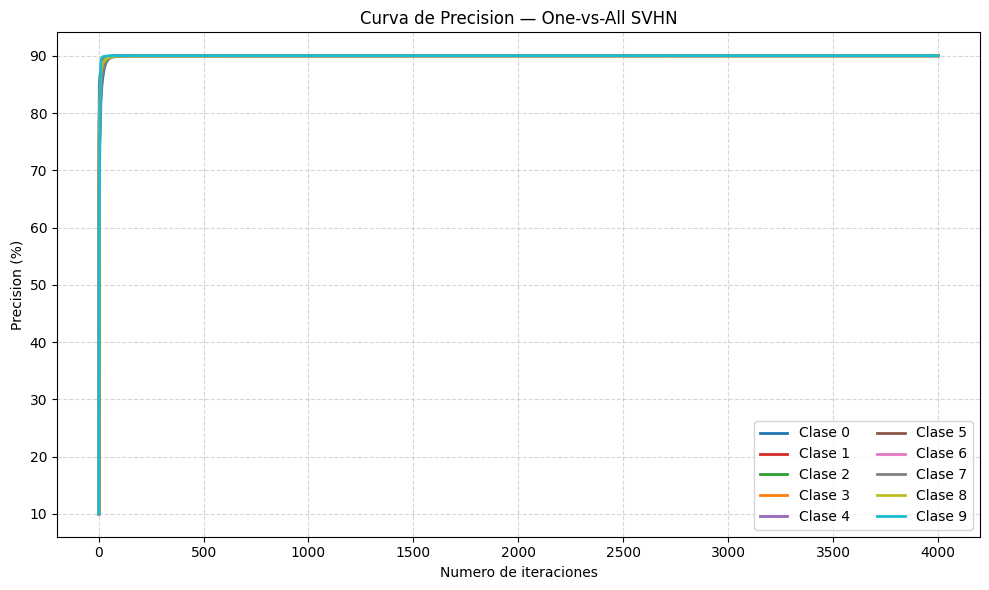

In [ ]:
lambda_ = 0.001
all_theta, mu, sigma = oneVsAll(X, y, num_labels, lambda_)

Clase 0 — costo final: 0.3141
Clase 1 — costo final: 0.3149
Clase 2 — costo final: 0.3093
Clase 3 — costo final: 0.3150
Clase 4 — costo final: 0.3095


/tmp/ipykernel_9705/2487971149.py:46: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))


Clase 5 — costo final: 0.3107
Clase 6 — costo final: 0.3142
Clase 7 — costo final: 0.3123
Clase 8 — costo final: 0.3147
Clase 9 — costo final: 0.3132


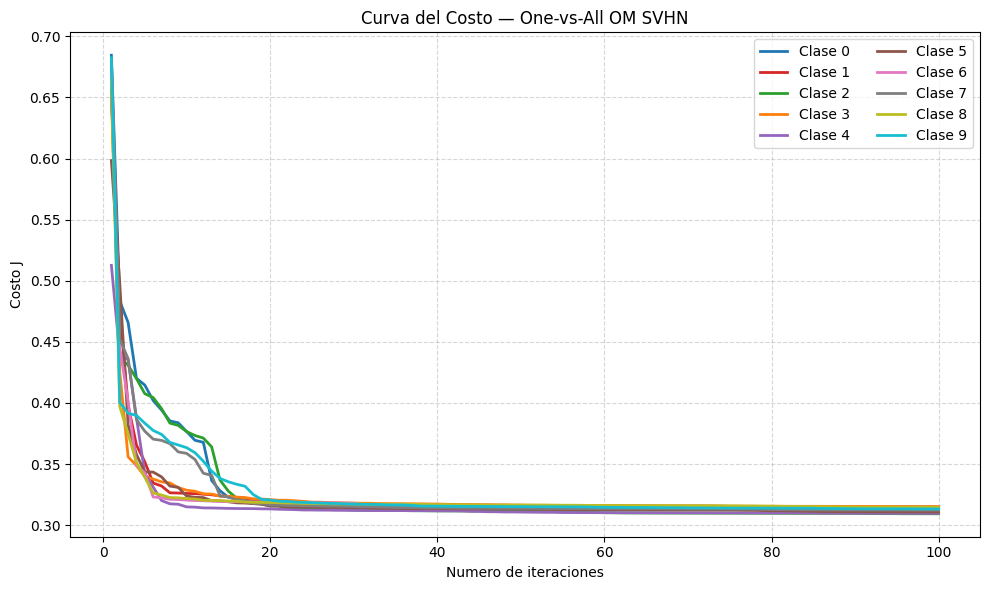

In [ ]:
lambda_ = 0.001
all_theta2, mu2, sigma2 = oneVsAllOM(X, y, num_labels, lambda_)


In [ ]:
print('valores de theta por decenso por el gradiente')
print(all_theta.shape)
print(all_theta[0])
print(' valores de theta por optimize.minimize')
print(all_theta2.shape)
print(all_theta2[0])

valores de theta por decenso por el gradiente
(10, 1025)
[-2.21814676e+00  1.54702141e-02  1.05437317e-02 ... -1.95231704e-03
  3.71108535e-03  3.43760041e-03]
 valores de theta por optimize.minimize
(10, 1025)
[-2.27839249  0.01989153 -0.01257564 ... -0.01104406  0.02507663
  0.02451452]


### 1.5 Predicción One-vs-All

Una vez entrenados los 10 clasificadores, la predicción para un nuevo ejemplo $x$ se obtiene calculando la probabilidad de cada clasificador y eligiendo la clase con mayor valor:

$$ \hat{y} = \arg\max_{k \in \{0,...,9\}} \; g\!\left(\theta_k^T x\right) $$

La función `predictOneVsAll` calcula esto de forma vectorizada para todos los ejemplos a la vez.

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

### 1.6 Evaluación del modelo y análisis de la precisión

Se evalúa el modelo tanto en el conjunto de entrenamiento como en el de prueba. Los resultados muestran una precisión de aproximadamente **20-25%**.

**¿Por qué la precisión es baja?**

Esto no es un error de implementación — es una limitación inherente del modelo. La regresión logística es un **clasificador lineal**: separa las clases mediante un hiperplano recto en el espacio de features. SVHN es un dataset de imágenes reales con:
- Fondos complejos y ruidosos
- Iluminación variable
- Dígitos vecinos visibles en los bordes
- Rotaciones y deformaciones

Estas características hacen que las clases **no sean linealmente separables**, por lo que ningún hiperplano puede separarlas correctamente.

**¿El modelo aprendió algo?**

Sí. Un clasificador que adivina al azar entre 10 clases obtendría exactamente el **10%** de precisión. El modelo obtiene ~20-25%, es decir, **duplica** la precisión de un clasificador aleatorio. El costo final menor a 1 y las curvas de convergencia confirman que el entrenamiento fue correcto.

Para obtener precisiones superiores al 80% con SVHN se requieren modelos no lineales como redes neuronales convolucionales (CNN), que pueden capturar las formas y patrones visuales que la regresión logística no puede representar.

(37272, 1024)
Precision del conjunto de entrenamiento: 25.94%
Precision del conjunto de prueba:        23.13%
(100, 1024)
(100, 1025)
[0 1 8 0 5 8 9 0 6 4 1 9 2 7 9 8 9 5 3 7 3 6 3 3 6 0 8 8 4 1 5 3 9 2 7 2 8
 5 4 9 1 3 6 7 5 3 4 2 5 7 0 7 5 6 0 0 7 7 3 0 5 6 9 4 0 2 1 6 0 8 5 5 4 1
 5 9 8 4 0 7 3 7 6 9 6 7 3 1 0 1 1 9 2 7 2 0 7 5 2 0] [0 8 4 0 7 4 7 0 5 5 0 0 8 8 5 5 8 6 7 5 6 6 9 0 5 0 8 9 7 0 7 9 6 5 1 8 3
 2 7 9 4 6 8 2 6 2 4 5 5 8 1 3 6 0 0 0 6 6 2 4 4 5 1 9 6 0 3 2 7 1 8 3 3 0
 6 9 5 9 5 1 3 5 2 3 2 0 3 1 4 8 8 9 7 2 7 5 7 0 1 0]


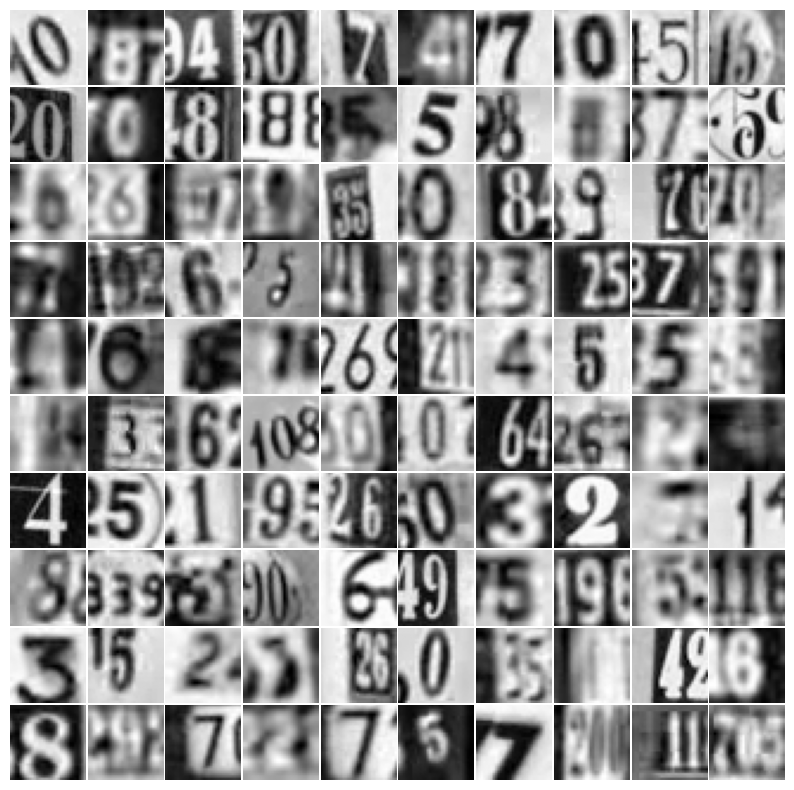

In [ ]:
print(X.shape)
X_norm      = (X      - mu) / sigma
X_test_norm = (X_test - mu) / sigma

pred = predictOneVsAll(all_theta, X_norm)
print('Precision del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))

pred_test = predictOneVsAll(all_theta, X_test_norm)
print('Precision del conjunto de prueba:        {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

rand_indices = np.random.choice(m, 100, replace=False)
XPrueba      = X_norm[rand_indices, :]
XPruebaV     = X[rand_indices, :]

print(XPrueba.shape)
XPrueba = np.concatenate([np.ones((100, 1)), XPrueba], axis=1)
print(XPrueba.shape)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)
print(p, y[rand_indices])

displayData(XPruebaV)

In [ ]:
# Evaluacion
X_norm2      = (X      - mu2) / sigma2
X_test_norm2 = (X_test - mu2) / sigma2

pred2      = predictOneVsAll(all_theta2, X_norm2)
pred_test2 = predictOneVsAll(all_theta2, X_test_norm2)

print('OneVsAllOM — Precision entrenamiento: {:.2f}%'.format(np.mean(pred2 == y) * 100))
print('OneVsAllOM — Precision prueba:        {:.2f}%'.format(np.mean(pred_test2 == y_test) * 100))

OneVsAllOM — Precision entrenamiento: 26.77%
OneVsAllOM — Precision prueba:        22.82%


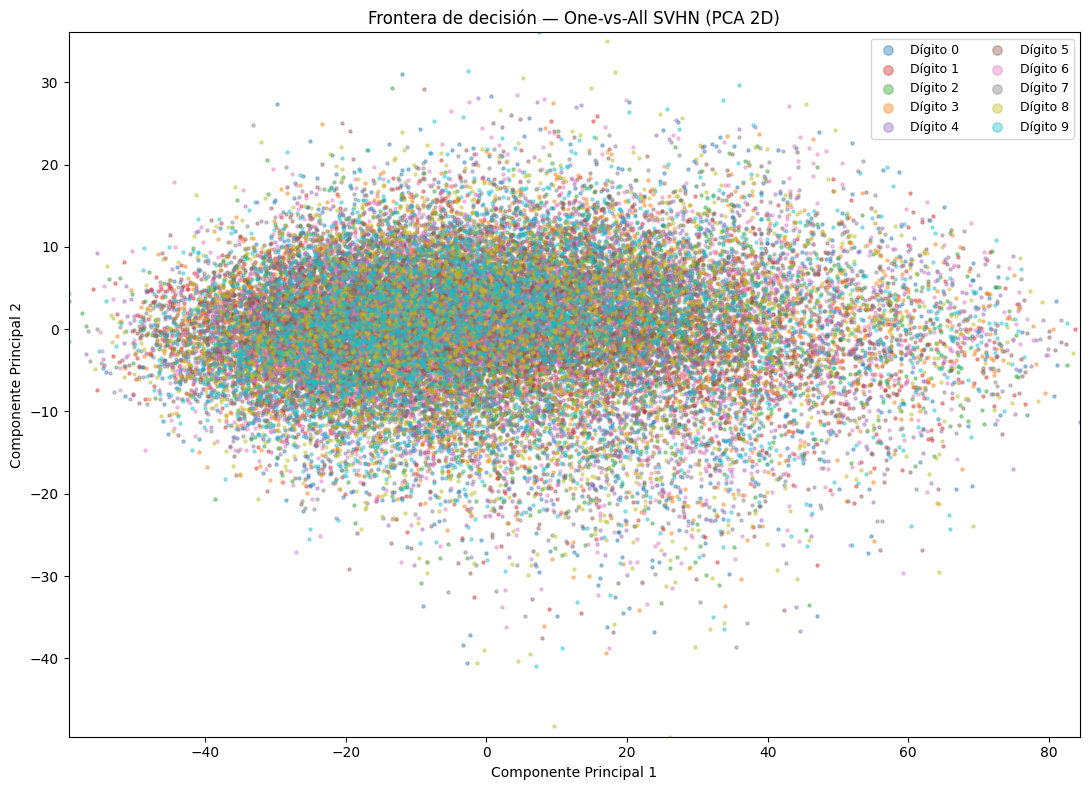

In [ ]:
from sklearn.decomposition import PCA

# Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2)
X_norm_train = (X - mu) / sigma
X_2d = pca.fit_transform(X_norm_train)

# Colores y nombres por clase
colores_clase = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd',
                 '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

# Graficar puntos por clase
fig, ax = pyplot.subplots(figsize=(11, 8))
for c in range(num_labels):
    idx = y == c
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               color=colores_clase[c], label=f'Dígito {c}',
               s=5, alpha=0.4)

# Graficar la frontera de decisión de cada clasificador
# Proyectar theta al espacio 2D via PCA
x1_range = np.linspace(X_2d[:, 0].min(), X_2d[:, 0].max(), 300)
x2_range = np.linspace(X_2d[:, 1].min(), X_2d[:, 1].max(), 300)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

# Reconstruir al espacio original para aplicar theta
X_grid = pca.inverse_transform(np.c_[xx1.ravel(), xx2.ravel()])
X_grid_b = np.concatenate([np.ones((X_grid.shape[0], 1)), X_grid], axis=1)

for c in range(num_labels):
    h_grid = sigmoid(X_grid_b.dot(all_theta[c]))
    h_grid = h_grid.reshape(xx1.shape)
    # Dibujar la línea donde h=0.5 (frontera de decisión)
    ax.contour(xx1, xx2, h_grid, levels=[0.5],
               colors=[colores_clase[c]], linewidths=2)

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_title('Frontera de decisión — One-vs-All SVHN (PCA 2D)')
ax.legend(markerscale=3, fontsize=9, ncol=2)
pyplot.tight_layout()
pyplot.show()